In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

Betragt rummet af differentiable funktioner $f: [0,\pi] \to \mathbb{R}$ med det $L^{2}$-indre produkt
$$
\left< f,g \right> = \int_{0}^{\pi} f(x)g(x) \, dx
$$

## (a) {-}

For alle heltal $k > 0$ vis at samlingen bestående af funktionerne
$$
\sin(x), \sin(2x), \dots, \sin(kx),
$$
defineret for $x \in [0,\pi]$, er ortogonal for dette indre produkt. (Trigonometriske identiter findes i notesættes afsnit 9.6; computeralgebra systemer, herunder sympy, kan eventuelt bruges for udregninger.)

To funktioner er vinkelrette, hvis det indre produkt mellem dem er nul. Det indre produkt mellem alle funktionerne i samlingen skal da tages. Alle funktionerne er sinusfunktioner med en skalar ganget på $x$. To vilkårlige positive heltal, $n$ og $m$, kan da ganges på hver sin sinus funktion for et generelt udtryk for alle funktionerne i samlingen. Dette gøres forneden med sympy.

In [2]:
x = sp.symbols('x')
n, m = sp.symbols('n m', integer=True, positive=True)
sp.integrate(sp.sin(n*x) * sp.sin(m*x), (x, 0, sp.pi))

Piecewise((0, Ne(m, n)), (pi/2, True))

Det kan ses at så længe $n$ og $m$ ikke er det samme tal vil $\sin(nx)$ og $\sin(mx)$ være vinkelrette. Når $n$ og $m$ er ens svarer det til den samme funktion, hvor det så giver mening, at det indre produkt ikke er 0, da det burde svare til $L^{2}$-normen af funktionen i anden potens.

$\pagebreak$

## (b) {-}

Gør rede for at funktionen $f(x) \equiv 1$ er ikke vinkelret på $\sin(x)$ eller på $\sin(3x)$, men er vinkelret på $\sin(2x)$ og $\sin(4x)$.

Det kan ses at $\sin(x)$ og $\sin(3x)$ har en generel form, som er sinus til et ulige tal ganget med $x$. Et vilkårligt ulige tal kan betegnes som 2k + 1. Når dette indsættes i det indre produkt fås følgendes udledning:

$$
\left< f,g \right> = \int_{0}^{\pi} 1 \cdot \sin((2k + 1) \cdot x) \, dx \\
\Updownarrow \\
\left< f,g \right> = -\frac{1}{2k + 1} \cdot [\cos((2k + 1) \cdot x)]_{0}^{\pi} \\
\Updownarrow \\
\left< f,g \right> = -\frac{1}{2k + 1} \cdot (\cos((2k + 1) \cdot \pi) - \cos((2k + 1) \cdot 0)) \\
\Updownarrow \\
\left< f,g \right> = -\frac{1}{2k + 1} \cdot (\cos((2k + 1) \cdot \pi) - 1) \\
\Updownarrow \\
\left< f,g \right> = \frac{1 - \cos((2k + 1) \cdot \pi)}{2k + 1} \\
\Updownarrow \\
\left< f,g \right> = \frac{1 - (-1)}{2k + 1} \\
\Updownarrow \\
\left< f,g \right> = \frac{2}{2k + 1}
$$

Det kan da ses, at det indre produkt mellem 1 og sinusfunktionen med en ulige faktor på $x$ ikke giver 0, hvilket betyder, at de ikke kan være vinkelrette. Da 1 og 3 er ulige, er $\sin(x)$ og $\sin(3x)$ heller ikke vinkelrette.

Omskrives de sidste tre linjer af beviset med et vilkårligt lige tal (2k), fås følgede:

$$
\left< f,g \right> = \frac{1 - \cos((2k) \cdot \pi)}{2k} \\
\Updownarrow \\
\left< f,g \right> = \frac{1 - 1}{2k + 1} \\
\Updownarrow \\
\left< f,g \right> = \frac{0}{2k + 1} \\
\Updownarrow \\
\left< f,g \right> = 0
$$

Her kan det ses at det indre produkt giver 0, hvilket betyder at 1 er vinkelret på alle sinusfunktioner med lige faktorer ganget på $x$. Da 2 og 4 er lige, må $\sin(2x)$ og $\sin(4x)$ da være vinkelrette.

$\pagebreak$

## (c) {-}

Bestem projektionen af $f(x) \equiv 1$ på $\sin(x)$, $\sin(3x)$ og find derfra en funktion af formen
$$
g(x) = 1 + c_{1} \sin(x) + c_{3} \sin(3x),
$$
som er vinkelret på både $\sin(x)$ og $\sin(3x)$. Forklar hvorfor $g(x)$ er vinkelret på alle funktioner i (8.1) for $k = 4$.

Som beskrevet i afsnit 14.1 i notesættet, kan en vinkelret vektor på en vektor ($v$) bestemmes ud fra en anden vektor $u$ ved at trække projektionen af $u$ på $v$ fra $u$, hvilket matematisk skrives således:
$$
u - pr_{v}(u)
$$
I dette tilfælde er vektorerne blot funktioner, hvor koefficienterne, $c_{1}$ og $c_{3}$, bliver projektionen uden funktionen ganget på til sidst, hvilket er det indre produkt delt med normen i anden. Det vides også at normen i anden svarer til det indre produkt med sig selv:
$$
\frac{\left< u,v \right>}{||v||^{2}} = \frac{\left< u,v \right>}{\left< v,v \right>}
$$

In [3]:
# Defineret ud fra det opgivne indre produkt
def indre_produkt(f, g):
    return sp.integrate(f * g, (x, 0, sp.pi))
# Defineret ud fra første formel i 14.1 fra notesættet
def proj_på(u, v):
    return (indre_produkt(u, v) / (indre_produkt(v, v))) * v

In [4]:
g = 1 - proj_på(1, sp.sin(x)) - proj_på(1, sp.sin(3 * x))
print("Funktionen g(x) bliver dermed:")
g

Funktionen g(x) bliver dermed:


-4*sin(x)/pi - 4*sin(3*x)/(3*pi) + 1

Dette betyder at $c_{1} = - \frac{4 \sin(x)}{\pi}$ og $c_{3} = - \frac{4 \sin(3x)}{3\pi}$.

Funktionen $g$ er opbygget, så den hvertfald er vinkelret på $\sin(x)$ og $\sin(3x)$. Ledvist er den også vinkelret på $\sin(2x)$ og $\sin(4x)$, hvilket beskrives for sinusfunktionerne i opgave a og 1 i opgave b. Gennem sum-reglen vides det, at da det gælder ledvist, gælder det også samlet. Validiteten af dette kan tjekkes således:

In [5]:
for i in range(4):
    print(indre_produkt(g, sp.sin(i * x)))

0
0
0
0


Da alle funktionerne for $k=4$ har et indreprodukt med $g$ på 0 er de vinkelrette på $g$.

$\pagebreak$

## (d) {-}

Den lineære kombination af ortogonale funktioner som ligger tættest på en anden funktion, er givet ved den anden funktion projiceret på den lineære kombination. Dette kan ses i eksempel 13.10 i notesættet. I dette tilfælde vil det være $f(x)$, som skal projiceres på alle de givne funktioner, hvorefter projektionerne skal summeres de forskellige projektioner. Projektionerne gøres numerisk i numpy forneden.

In [6]:
# Definering af numerisk integrationsfunktioner fra afsnit 13.3 i notesættet
x, h = np.linspace(0, np.pi, 2000, retstep=True)

def trapez(f, h):
    return h * (f[0] + 2*np.sum(f[1:-1]) + f[-1]) / 2

def indre_produkt(f, g):
    return trapez(f * g, h)

# Denne funktion er blot projektion uden at gange på funktionen, da disse koefficienter bruges til at printe funktionen senere
def find_c(u, v):
    return (indre_produkt(u, v) / (indre_produkt(v, v)))

In [7]:
f = (np.exp(x) - np.exp(-x)) * (np.exp(np.pi - x) - np.exp(x - np.pi))
g = 1 - (4 * np.sin(x)) / np.pi - (4 * np.sin(3 * x)) / (3 * np.pi)

c0 = find_c(f, g)
c1 = find_c(f, np.sin(x))
c2 = find_c(f, np.sin(2 * x))
c3 = find_c(f, np.sin(3 * x))
c4 = find_c(f, np.sin(4 * x))

print(f"Den endelige lineære kombination ender da med at være følgende:\nf(x) ≈ {c0} g(x) + {c1} sin(x) + {c2} sin(2x) + {c3} sin(3x) + {c4} sin(4x)")

Den endelige lineære kombination ender da med at være følgende:
f(x) ≈ 1.5653338512586041 g(x) + 23.61493329778307 sin(x) + 0.0 sin(2x) + 3.0275555509892094 sin(3x) + -4.549748383056169e-16 sin(4x)


$\pagebreak$

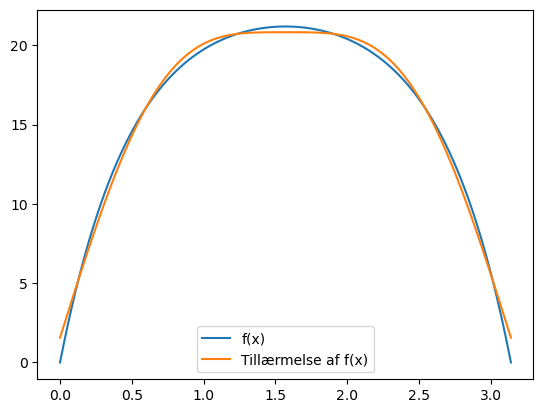

In [11]:
fig, ax = plt.subplots()
ax.plot(x, f, label="f(x)")
ax.plot(x, c0 * g + c1 * np.sin(x) + c2 * np.sin(2 * x) + c3 * np.sin(3 * x) + c4 * np.sin(4 * x), label="Tillærmelse af f(x)")
ax.legend()